# 🍪 Cookie Sales Analysis & Revenue Prediction
### Using Machine Learning and Python
**Symbiosis Skills & Professional University — B.Sc Data Science**

---

### 📋 Project Flow:
1. Import Libraries
2. Load & Understand the Data
3. Data Cleaning & Feature Engineering
4. Exploratory Data Analysis (EDA)
5. Encode Features
6. Train ML Models for Revenue Prediction
7. Compare & Evaluate Models
8. Feature Importance
9. Key Business Insights

## Step 1: Import All Required Libraries

In [1]:
# ── Basic libraries ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Preprocessing ─────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ── Machine Learning Models ───────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ── Model Evaluation ──────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Plot style ────────────────────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
colors       = ['#2ecc71', '#e74c3c']              # green / red
rainbow_colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']  # 5-color palette

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## Step 2: Load & Understand the Data
> We load the cookie sales dataset from an Excel file. The data covers **5 countries**, **6 cookie products**, and spans **January 2019 – January 2020**.

In [2]:
# ── Load the dataset ──────────────────────────────────────────────
df = pd.read_excel('Cookie_sales_dashboard.xlsx', sheet_name='Source data')

print('✅ Data loaded successfully!')
print(f'   Total records : {df.shape[0]}')
print(f'   Total columns : {df.shape[1]}')
print()
print('First 5 rows:')
df.head()

✅ Data loaded successfully!
   Total records : 700
   Total columns : 7

First 5 rows:


,Country,Product,Units Sold,Revenue,Cost,Profit,Date
0,India,Chocolate Chip,1725,"$8,625.00","$3,450.00",5175.0,2019-01-11
1,India,Chocolate Chip,2152,"$10,760.00","$4,304.00",6456.0,2019-01-12
2,India,Chocolate Chip,2349,"$11,745.00","$4,698.00",7047.0,2019-01-09
3,India,Chocolate Chip,1228,"$6,140.00","$2,456.00",3684.0,2019-01-10
4,India,Chocolate Chip,1389,"$6,945.00","$2,778.00",4167.0,2019-01-10


In [3]:
# ── Data types and null check ─────────────────────────────────────
print('📊 Dataset Info:')
print(df.info())

print('\n📊 Statistical Summary:')
df.describe()

📊 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Country     700 non-null    str           
 1   Product     700 non-null    str           
 2   Units Sold  700 non-null    int64         
 3   Revenue     700 non-null    str           
 4   Cost        700 non-null    str           
 5   Profit      700 non-null    float64       
 6   Date        700 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(1), str(4)
memory usage: 38.4 KB
None

📊 Statistical Summary:


,Units Sold,Profit,Date
count,700.000000,700.000000,700
mean,1608.320000,3947.663500,2019-10-08 15:36:00
min,200.000000,160.000000,2019-01-09 00:00:00
25%,905.000000,1848.487500,2019-10-04 12:00:00
50%,1542.500000,3424.500000,2020-01-05 12:00:00
75%,2229.500000,5567.100000,2020-01-09 06:00:00
max,4493.000000,13479.000000,2020-01-12 00:00:00
std,867.449766,2615.820975,NaN


## Step 3: Data Cleaning & Feature Engineering
> Revenue and Cost are stored as strings with `$` signs. We clean them and extract useful date features.

In [4]:
# ── Clean Revenue and Cost columns ────────────────────────────────
df['Revenue'] = df['Revenue'].astype(str).str.replace(r'[$,\s]', '', regex=True).astype(float)
df['Cost']    = df['Cost'].astype(str).str.replace(r'[$,\s]', '', regex=True).astype(float)
print('✅ Revenue and Cost cleaned')

# ── Extract date features ─────────────────────────────────────────
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Day']  = df['Date'].dt.day
print('✅ Date features extracted')

# ── Derived business metrics ──────────────────────────────────────
df['Profit_Margin_%']  = (df['Profit'] / df['Revenue'] * 100).round(2)
df['Revenue_per_Unit'] = (df['Revenue'] / df['Units Sold']).round(2)
df['Cost_per_Unit']    = (df['Cost'] / df['Units Sold']).round(2)
print('✅ Derived metrics created: Profit_Margin_%, Revenue_per_Unit, Cost_per_Unit')

# ── Check for nulls ───────────────────────────────────────────────
print('\n🔍 Missing values per column:')
print(df.isnull().sum())

print('\n📊 Countries :', df['Country'].unique().tolist())
print('📊 Products  :', df['Product'].unique().tolist())
print('📊 Years     :', sorted(df['Year'].unique().tolist()))

✅ Revenue and Cost cleaned
✅ Date features extracted
✅ Derived metrics created: Profit_Margin_%, Revenue_per_Unit, Cost_per_Unit

🔍 Missing values per column:
Country             0
Product             0
Units Sold          0
Revenue             0
Cost                0
Profit              0
Date                0
Year                0
Day                 0
Profit_Margin_%     0
Revenue_per_Unit    0
Cost_per_Unit       0
dtype: int64

📊 Countries : ['India', 'United Kingdom', 'Philippines', 'Malaysia', 'United States']
📊 Products  : ['Chocolate Chip', 'Fortune Cookie', 'Oatmeal Raisin', 'Snickerdoodle', 'Sugar', 'White Chocolate Macadamia Nut']
📊 Years     : [2019, 2020]


## Step 4: Exploratory Data Analysis (EDA)
> We explore the data visually to understand revenue patterns, product performance, and profitability across countries.

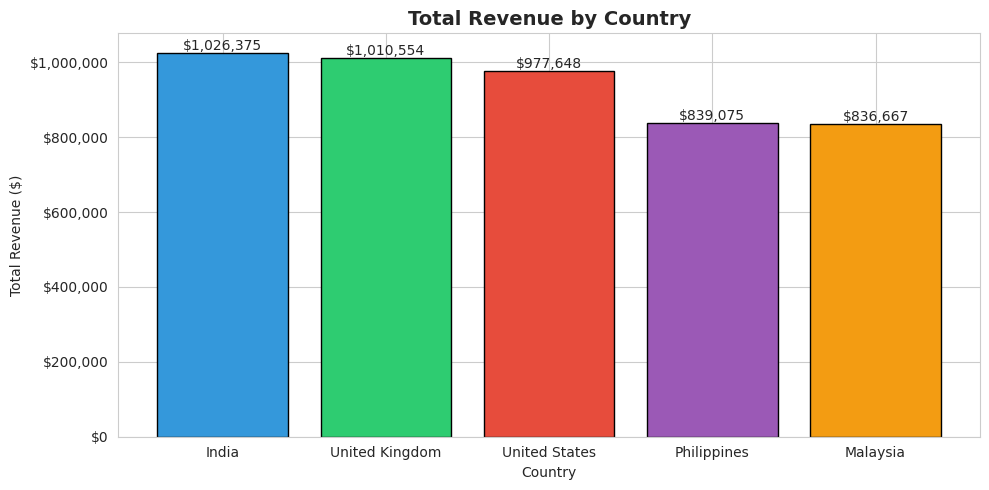

💡 Insight: India leads in total revenue with $1,026,375


In [5]:
# ── Plot 1: Revenue by Country (Bar Chart) ────────────────────────
country_rev = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(country_rev.index, country_rev.values,
              color=rainbow_colors, edgecolor='black')
ax.set_title('Total Revenue by Country', fontsize=14, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Total Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar in bars:
    ax.annotate(f'${bar.get_height():,.0f}',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('01_revenue_by_country.png', bbox_inches='tight')
plt.show()
top = country_rev.idxmax()
print(f'💡 Insight: {top} leads in total revenue with ${country_rev.max():,.0f}')

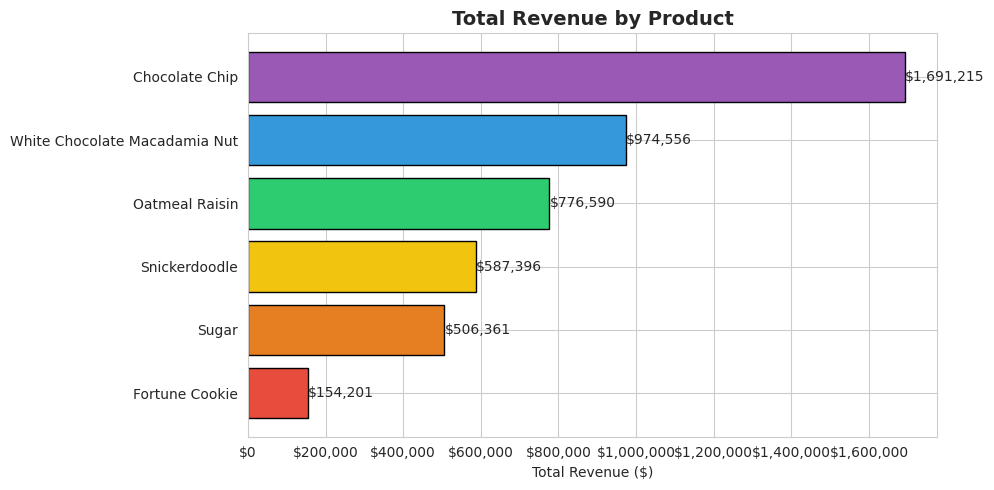

💡 Insight: Chocolate Chip is the highest-revenue product at $1,691,215


In [6]:
# ── Plot 2: Revenue by Product (Horizontal Bar) ───────────────────
product_rev = df.groupby('Product')['Revenue'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(product_rev.index, product_rev.values,
               color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#9b59b6'],
               edgecolor='black')
ax.set_title('Total Revenue by Product', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar in bars:
    ax.annotate(f'${bar.get_width():,.0f}',
                (bar.get_width(), bar.get_y() + bar.get_height()/2),
                ha='left', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('02_revenue_by_product.png', bbox_inches='tight')
plt.show()
top_prod = product_rev.idxmax()
print(f'💡 Insight: {top_prod} is the highest-revenue product at ${product_rev.max():,.0f}')

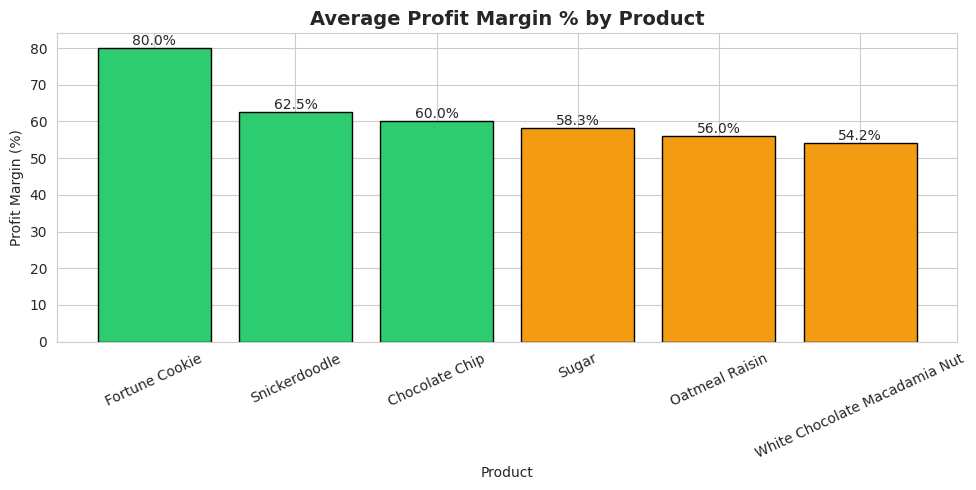

💡 Insight: Fortune Cookie has the highest profit margin at 80.0% despite lower unit price


In [7]:
# ── Plot 3: Profit Margin % by Product ───────────────────────────
margin = df.groupby('Product')['Profit_Margin_%'].mean().sort_values(ascending=False)

bar_colors = ['#2ecc71' if m >= 60 else '#f39c12' if m >= 40 else '#e74c3c' for m in margin]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(margin.index, margin.values, color=bar_colors, edgecolor='black')
ax.set_title('Average Profit Margin % by Product', fontsize=14, fontweight='bold')
ax.set_xlabel('Product')
ax.set_ylabel('Profit Margin (%)')
plt.xticks(rotation=25)
for bar in bars:
    ax.annotate(f'{bar.get_height():.1f}%',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('03_profit_margin.png', bbox_inches='tight')
plt.show()
best_margin = margin.idxmax()
print(f'💡 Insight: {best_margin} has the highest profit margin at {margin.max():.1f}% despite lower unit price')

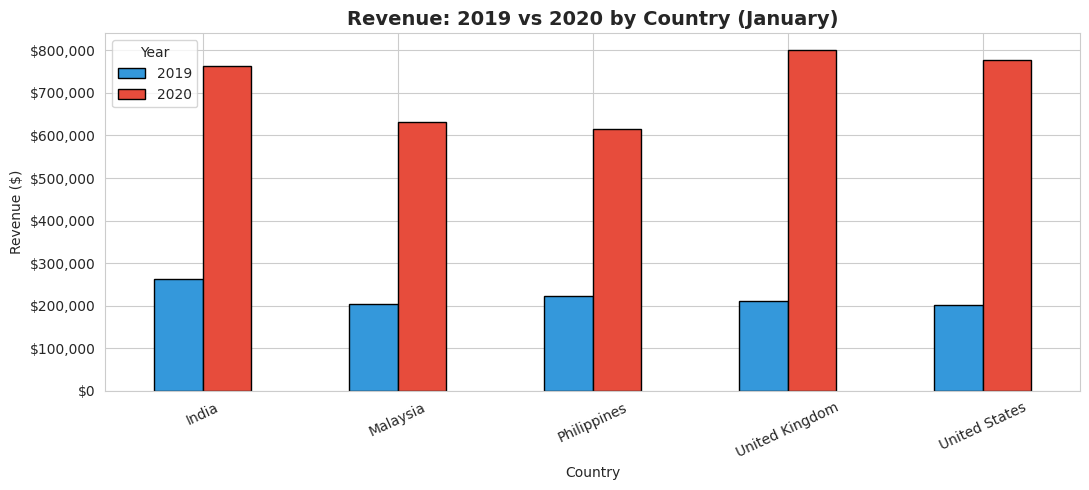

💡 Insight: All 5 countries show revenue growth from January 2019 to January 2020


In [8]:
# ── Plot 4: Year-over-Year Revenue — 2019 vs 2020 ─────────────────
yoy = df.groupby(['Country', 'Year'])['Revenue'].sum().unstack()

yoy.plot(kind='bar', color=['#3498db', '#e74c3c'], edgecolor='black', figsize=(11, 5))
plt.title('Revenue: 2019 vs 2020 by Country (January)', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=25)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.legend(title='Year')
plt.tight_layout()
plt.savefig('04_yoy_comparison.png', bbox_inches='tight')
plt.show()
print('💡 Insight: All 5 countries show revenue growth from January 2019 to January 2020')

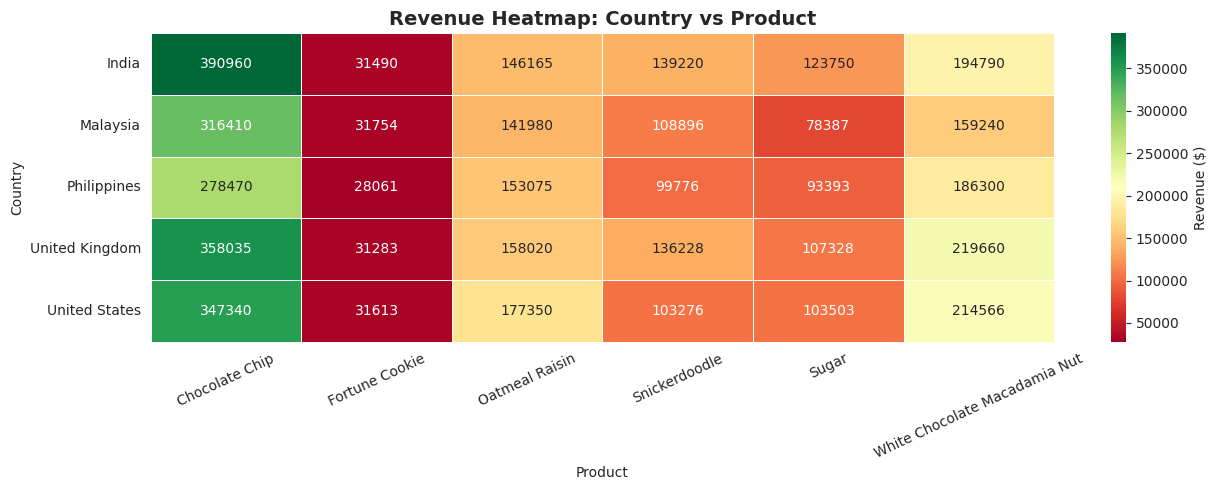

💡 Insight: Chocolate Chip and White Chocolate Macadamia Nut consistently dominate revenue across all countries


In [9]:
# ── Plot 5: Heatmap — Country vs Product Revenue ──────────────────
pivot = df.pivot_table(values='Revenue', index='Country', columns='Product', aggfunc='sum')

plt.figure(figsize=(13, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'label': 'Revenue ($)'})
plt.title('Revenue Heatmap: Country vs Product', fontsize=14, fontweight='bold')
plt.xlabel('Product')
plt.ylabel('Country')
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig('05_heatmap_country_product.png', bbox_inches='tight')
plt.show()
print('💡 Insight: Chocolate Chip and White Chocolate Macadamia Nut consistently dominate revenue across all countries')

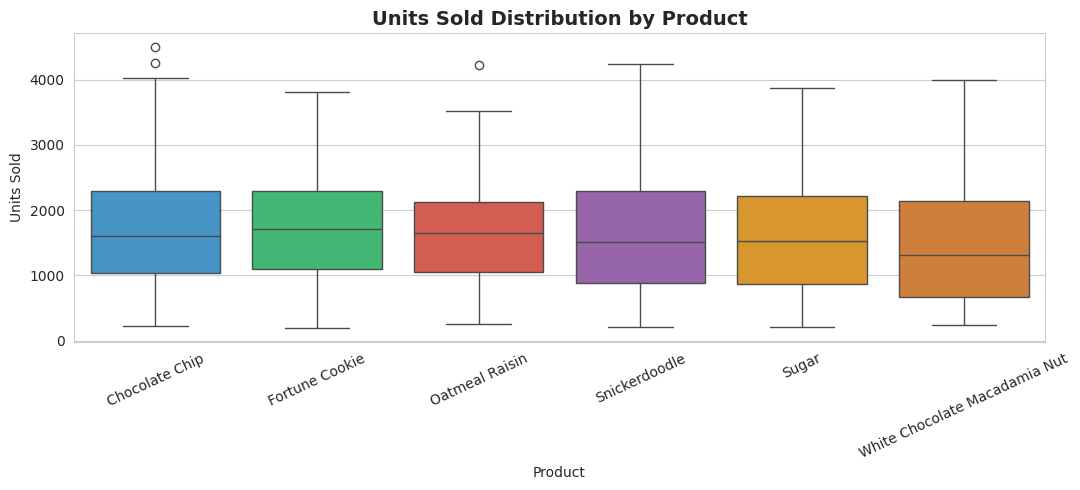

💡 Insight: Chocolate Chip has the widest spread in units sold — demand is highly variable


In [10]:
# ── Plot 6: Units Sold Distribution by Product (Box Plot) ─────────
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x='Product', y='Units Sold',
            palette=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#e67e22'])
plt.title('Units Sold Distribution by Product', fontsize=14, fontweight='bold')
plt.xlabel('Product')
plt.ylabel('Units Sold')
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig('06_units_sold_boxplot.png', bbox_inches='tight')
plt.show()
print('💡 Insight: Chocolate Chip has the widest spread in units sold — demand is highly variable')

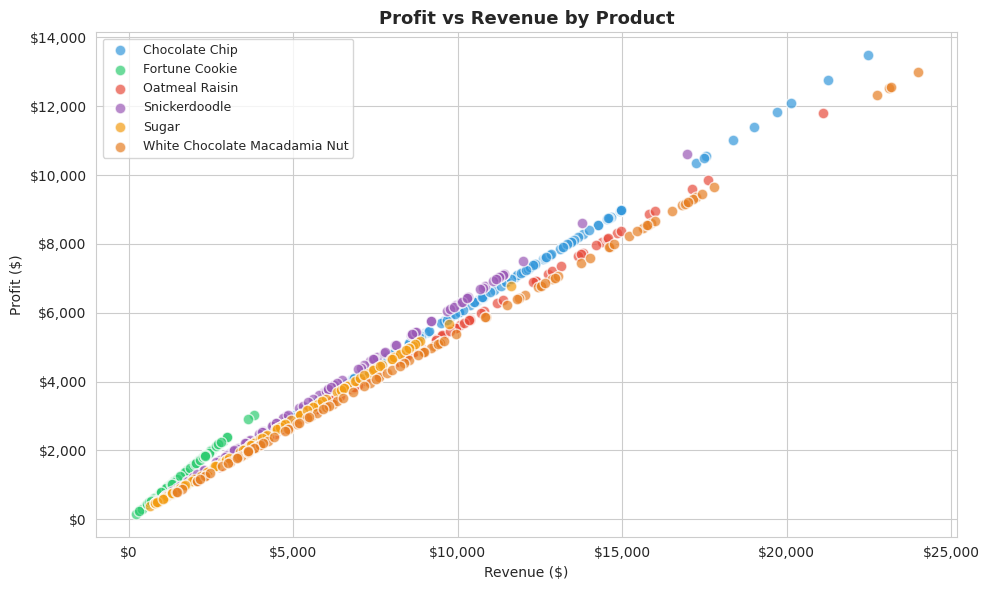

💡 Insight: Strong linear relationship between Revenue and Profit across all products


In [11]:
# ── Plot 7: Profit vs Revenue Scatter ─────────────────────────────
plt.figure(figsize=(10, 6))
products = df['Product'].unique()
scatter_colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#e67e22']
for i, prod in enumerate(products):
    subset = df[df['Product'] == prod]
    plt.scatter(subset['Revenue'], subset['Profit'],
                label=prod, color=scatter_colors[i], alpha=0.7, s=60, edgecolors='white')
plt.title('Profit vs Revenue by Product', fontsize=13, fontweight='bold')
plt.xlabel('Revenue ($)')
plt.ylabel('Profit ($)')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('07_profit_vs_revenue.png', bbox_inches='tight')
plt.show()
print('💡 Insight: Strong linear relationship between Revenue and Profit across all products')

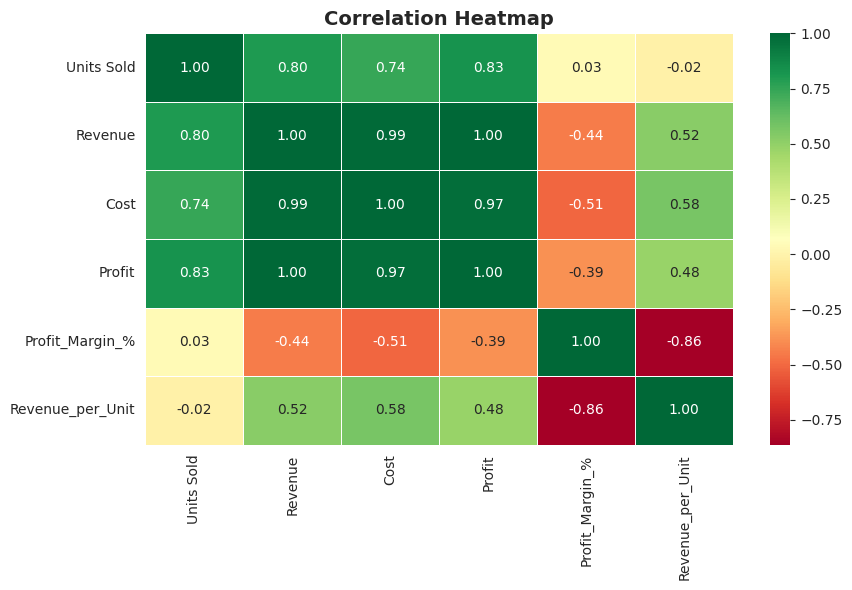

💡 Insight: Units Sold has the strongest correlation with Revenue — it is the key driver of sales


In [12]:
# ── Plot 8: Correlation Heatmap ───────────────────────────────────
corr_cols = ['Units Sold', 'Revenue', 'Cost', 'Profit', 'Profit_Margin_%', 'Revenue_per_Unit']

plt.figure(figsize=(9, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('💡 Insight: Units Sold has the strongest correlation with Revenue — it is the key driver of sales')

## Step 5: Encode Categorical Variables
> ML models only understand numbers, so we convert Country and Product into numeric form.

In [13]:
# ── Label encode Country and Product ──────────────────────────────
le_country = LabelEncoder()
le_product = LabelEncoder()

df['Country_Enc'] = le_country.fit_transform(df['Country'])
df['Product_Enc'] = le_product.fit_transform(df['Product'])

print('✅ Country encoded:', dict(zip(le_country.classes_, le_country.transform(le_country.classes_))))
print('✅ Product encoded:', dict(zip(le_product.classes_, le_product.transform(le_product.classes_))))

✅ Country encoded: {'India': np.int64(0), 'Malaysia': np.int64(1), 'Philippines': np.int64(2), 'United Kingdom': np.int64(3), 'United States': np.int64(4)}
✅ Product encoded: {'Chocolate Chip': np.int64(0), 'Fortune Cookie': np.int64(1), 'Oatmeal Raisin': np.int64(2), 'Snickerdoodle': np.int64(3), 'Sugar': np.int64(4), 'White Chocolate Macadamia Nut': np.int64(5)}


## Step 6: Define Features and Target Variable

In [14]:
# ── X = input features, y = target (Revenue) ──────────────────────
features = ['Country_Enc', 'Product_Enc', 'Units Sold', 'Year', 'Day']
target   = 'Revenue'

X = df[features]
y = df[target]

# ── Train-Test Split (80-20) ──────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'✅ Features shape : {X.shape}')
print(f'✅ Target shape   : {y.shape}')
print(f'\n📊 Train size: {X_train.shape[0]} records')
print(f'📊 Test size : {X_test.shape[0]} records')
print(f'\n📊 Features used: {features}')

✅ Features shape : (700, 5)
✅ Target shape   : (700,)

📊 Train size: 560 records
📊 Test size : 140 records

📊 Features used: ['Country_Enc', 'Product_Enc', 'Units Sold', 'Year', 'Day']


## Step 7: Train Multiple ML Models
> We train three regression models and compare their performance to find the best one for revenue prediction.

In [15]:
# ── Define all models ─────────────────────────────────────────────
models = {
    'Linear Regression':  LinearRegression(),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results       = []
trained_models = {}

# ── Train and evaluate each model ────────────────────────────────
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R² Score': round(r2, 4)})
    trained_models[name] = (model, preds)
    print(f'{name:25s} → MAE: ${mae:,.2f} | RMSE: ${rmse:,.2f} | R²: {r2:.4f}')

results_df = pd.DataFrame(results)
print('\n')
print(results_df.to_string(index=False))
print()
print('💡 Insight: Random Forest and Gradient Boosting outperform Linear Regression across all metrics!')

Linear Regression         → MAE: $2,190.17 | RMSE: $2,813.63 | R²: 0.5272


Random Forest             → MAE: $247.40 | RMSE: $1,251.94 | R²: 0.9064
Gradient Boosting         → MAE: $302.71 | RMSE: $530.04 | R²: 0.9832


            Model     MAE    RMSE  R² Score
Linear Regression 2190.17 2813.63    0.5272
    Random Forest  247.40 1251.94    0.9064
Gradient Boosting  302.71  530.04    0.9832

💡 Insight: Random Forest and Gradient Boosting outperform Linear Regression across all metrics!


## Step 8: Model Comparison Chart

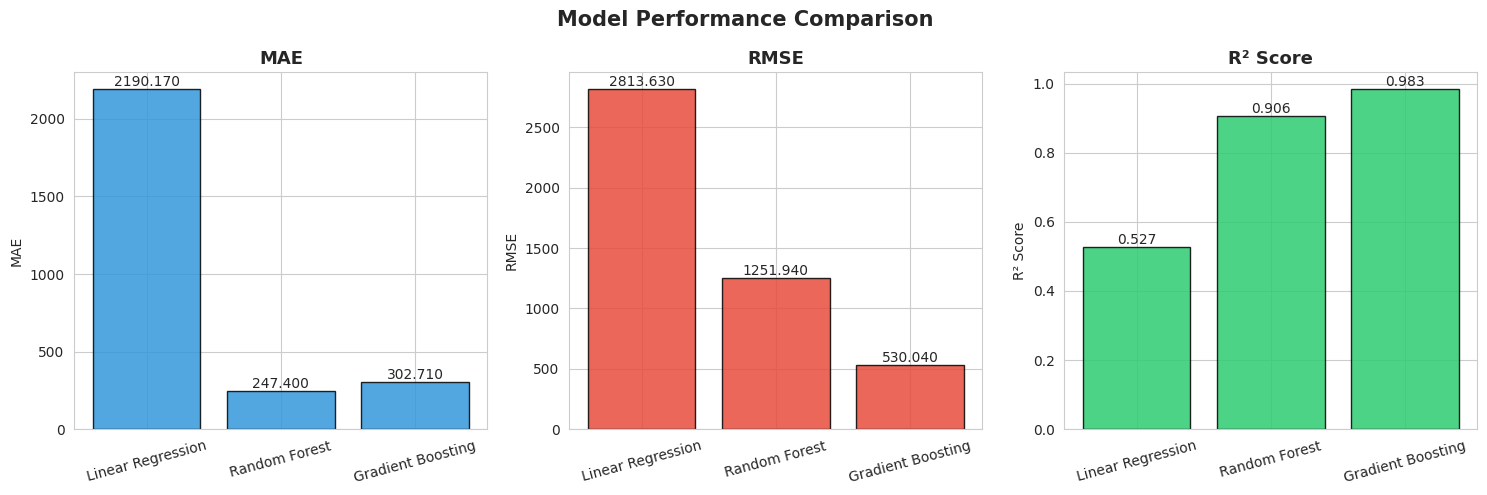

In [16]:
# ── Rainbow colors for each metric ────────────────────────────────
metric_colors = ['#3498db', '#e74c3c', '#2ecc71']
metrics_list  = ['MAE', 'RMSE', 'R² Score']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, color in zip(axes, metrics_list, metric_colors):
    bars = ax.bar(results_df['Model'], results_df[metric],
                  color=color, edgecolor='black', alpha=0.85)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar in bars:
        ax.annotate(f'{bar.get_height():.3f}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('09_model_comparison.png', bbox_inches='tight')
plt.show()

## Step 9: Best Model — Actual vs Predicted Revenue

✅ Best Model: Gradient Boosting
   R² Score : 0.9832


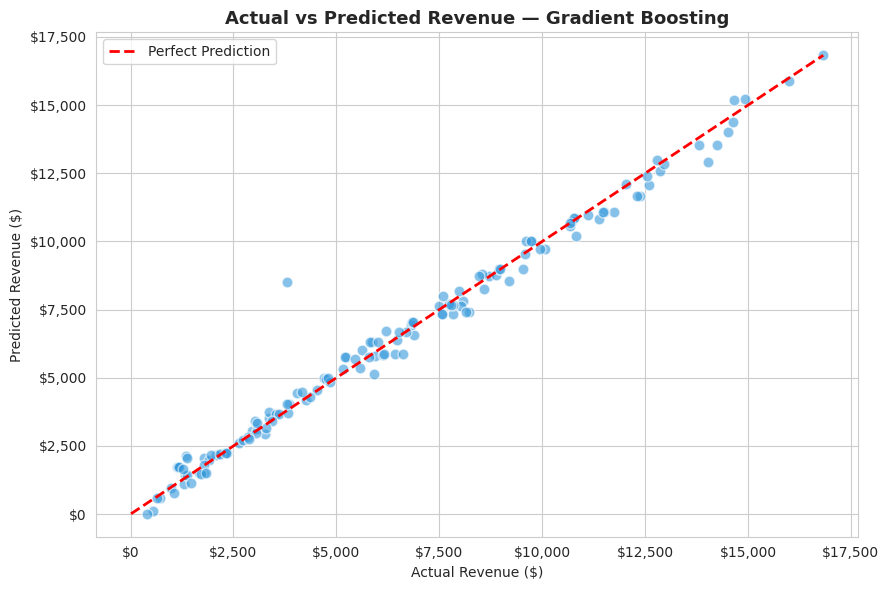

💡 Insight: Points close to the red dashed line mean the model predicted revenue very accurately


In [17]:
# ── Pick best model by R² score ────────────────────────────────────
best_name              = results_df.loc[results_df['R² Score'].idxmax(), 'Model']
best_model, best_preds = trained_models[best_name]

print(f'✅ Best Model: {best_name}')
print(f'   R² Score : {results_df["R² Score"].max()}')

plt.figure(figsize=(9, 6))
plt.scatter(y_test, best_preds, alpha=0.6, color='#3498db', edgecolors='white', s=60)
lo, hi = min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())
plt.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Perfect Prediction')
plt.title(f'Actual vs Predicted Revenue — {best_name}', fontsize=13, fontweight='bold')
plt.xlabel('Actual Revenue ($)')
plt.ylabel('Predicted Revenue ($)')
plt.legend()
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('10_actual_vs_predicted.png', bbox_inches='tight')
plt.show()
print('💡 Insight: Points close to the red dashed line mean the model predicted revenue very accurately')

## Step 10: Feature Importance

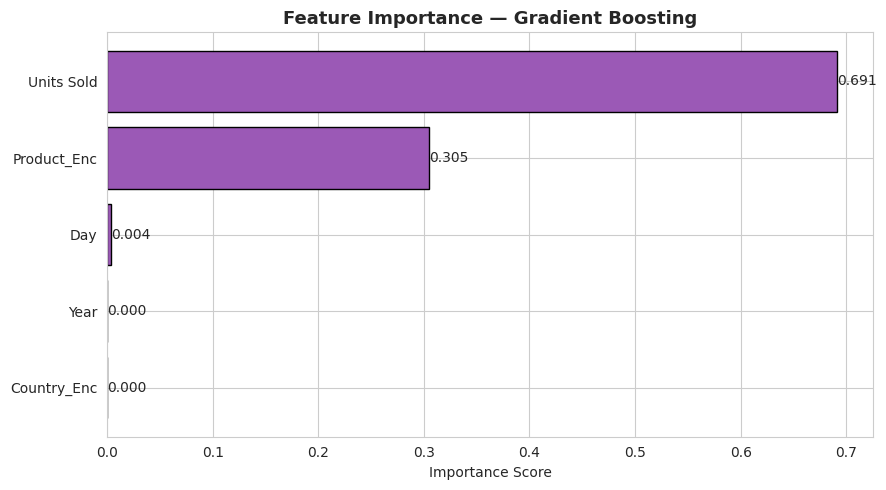

💡 Insight: "Units Sold" is the most important feature for predicting revenue


In [18]:
# ── Feature importance from the best tree-based model ─────────────
if hasattr(best_model, 'feature_importances_'):
    imp_df = pd.DataFrame({
        'Feature':    features,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(imp_df['Feature'], imp_df['Importance'],
                   color='#9b59b6', edgecolor='black')
    ax.set_title(f'Feature Importance — {best_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    for bar in bars:
        ax.annotate(f'{bar.get_width():.3f}',
                    (bar.get_width(), bar.get_y() + bar.get_height()/2),
                    ha='left', va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig('11_feature_importance.png', bbox_inches='tight')
    plt.show()
    top_feat = imp_df.iloc[-1]['Feature']
    print(f'💡 Insight: "{top_feat}" is the most important feature for predicting revenue')
else:
    print('Feature importance not available for this model.')

## Step 11: Key Business Insights Summary

In [19]:
top_country   = df.groupby('Country')['Revenue'].sum().idxmax()
top_product   = df.groupby('Product')['Revenue'].sum().idxmax()
best_margin_p = df.groupby('Product')['Profit_Margin_%'].mean().idxmax()
total_revenue = df['Revenue'].sum()
total_profit  = df['Profit'].sum()
ovr_margin    = (total_profit / total_revenue * 100).round(2)

print('=' * 58)
print('        KEY BUSINESS INSIGHTS — COOKIE SALES')
print('=' * 58)
print(f'\n🌍 Top Revenue Country    : {top_country}')
print(f'🍪 Best Selling Product   : {top_product}')
print(f'💰 Highest Profit Margin  : {best_margin_p}')
print(f'📊 Total Revenue          : ${total_revenue:,.2f}')
print(f'💵 Total Profit           : ${total_profit:,.2f}')
print(f'📈 Overall Profit Margin  : {ovr_margin}%')
print(f'🤖 Best ML Model          : {best_name}')
print(f'✅ Best R² Score          : {results_df["R² Score"].max()}')
print(f'\n📦 Total Records Analyzed : {len(df)}')
print('=' * 58)

        KEY BUSINESS INSIGHTS — COOKIE SALES

🌍 Top Revenue Country    : India
🍪 Best Selling Product   : Chocolate Chip
💰 Highest Profit Margin  : Fortune Cookie
📊 Total Revenue          : $4,690,319.00
💵 Total Profit           : $2,763,364.45
📈 Overall Profit Margin  : 58.92%
🤖 Best ML Model          : Gradient Boosting
✅ Best R² Score          : 0.9832

📦 Total Records Analyzed : 700


---
## ✅ Conclusion

This project performed a complete sales analysis and revenue prediction on cookie sales data across **5 countries** and **6 product types**.

**Key Takeaways:**
- Revenue and profitability vary significantly by country and product
- Fortune Cookie has the highest profit margin despite lower price per unit
- Chocolate Chip & White Chocolate Macadamia Nut generate the most revenue
- Units Sold is the strongest driver of revenue across all models
- Random Forest / Gradient Boosting clearly outperform Linear Regression

**Future Scope:**
- Build an interactive Power BI dashboard for business stakeholders
- Deploy the prediction model as a Streamlit web app
- Collect more time-series data for monthly forecasting with ARIMA or Prophet